In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/Disaster_dataset.csv", sep=";")

print(df.head())

   Year     Country  ISO Disaster Group Disaster Subroup      Disaster Type  \
0  1900  Cabo Verde  CPV        Natural   Climatological            Drought   
1  1900       India  IND        Natural   Climatological            Drought   
2  1900     Jamaica  JAM        Natural     Hydrological              Flood   
3  1900       Japan  JPN        Natural      Geophysical  Volcanic activity   
4  1900      Turkey  TUR        Natural      Geophysical         Earthquake   

  Disaster Subtype  Total Events  Total Affected  Total Deaths  \
0          Drought             1             NaN       11000.0   
1          Drought             1             NaN     1250000.0   
2              NaN             1             NaN         300.0   
3         Ash fall             1             NaN          30.0   
4  Ground movement             1             NaN         140.0   

   Total Damage (USD, original)  Total Damage (USD, adjusted)              CPI  
0                           NaN                

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/Disaster_dataset.csv", sep=";")

print(df.head())

   Year     Country  ISO Disaster Group Disaster Subroup      Disaster Type  \
0  1900  Cabo Verde  CPV        Natural   Climatological            Drought   
1  1900       India  IND        Natural   Climatological            Drought   
2  1900     Jamaica  JAM        Natural     Hydrological              Flood   
3  1900       Japan  JPN        Natural      Geophysical  Volcanic activity   
4  1900      Turkey  TUR        Natural      Geophysical         Earthquake   

  Disaster Subtype  Total Events  Total Affected  Total Deaths  \
0          Drought             1             NaN       11000.0   
1          Drought             1             NaN     1250000.0   
2              NaN             1             NaN         300.0   
3         Ash fall             1             NaN          30.0   
4  Ground movement             1             NaN         140.0   

   Total Damage (USD, original)  Total Damage (USD, adjusted)              CPI  
0                           NaN                

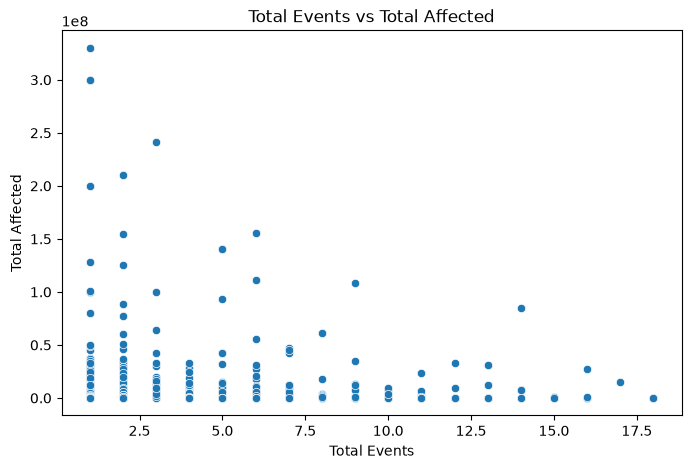

In [3]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Total Events",
    y="Total Affected"
)

plt.title("Total Events vs Total Affected")
plt.xlabel("Total Events")
plt.ylabel("Total Affected")

plt.show()

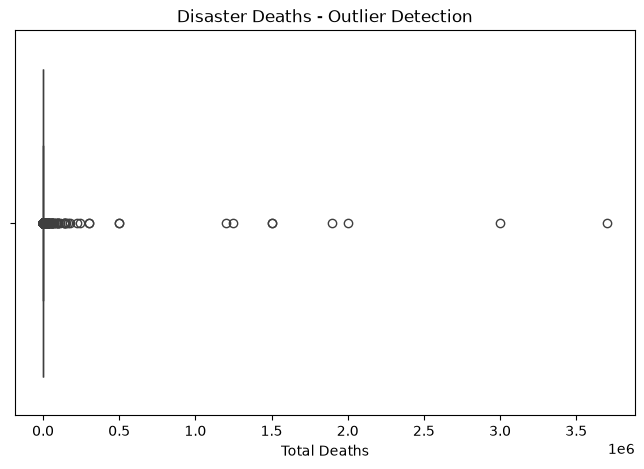

In [4]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["Total Deaths"]
)

plt.title("Disaster Deaths - Outlier Detection")
plt.xlabel("Total Deaths")

plt.show()

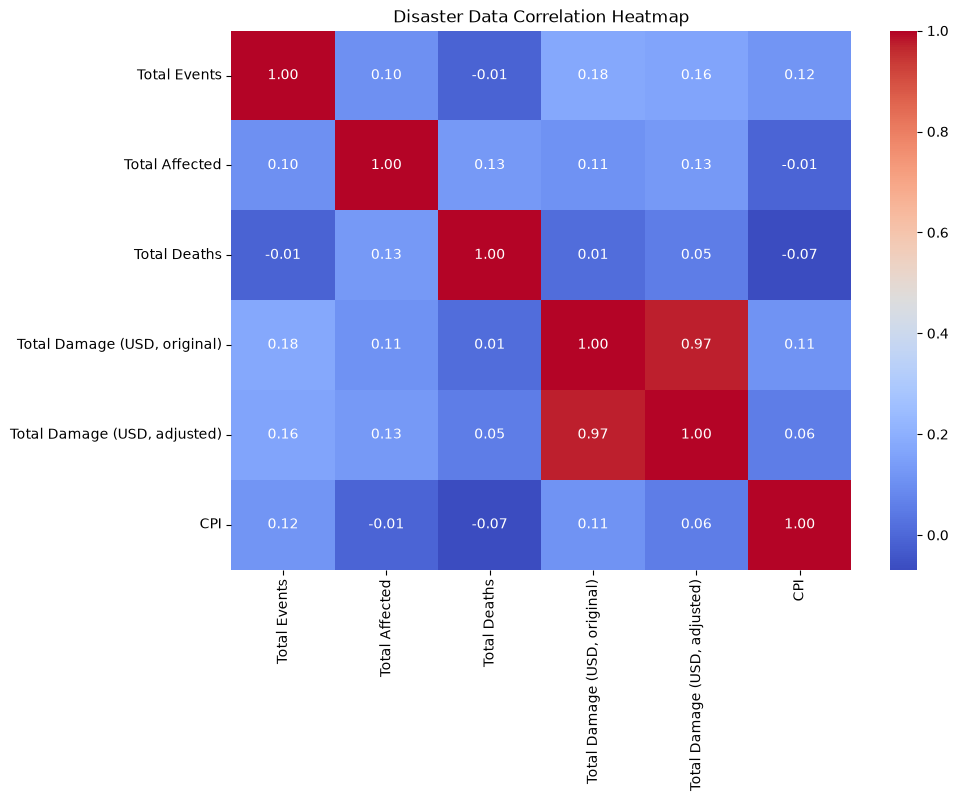

In [6]:
plt.figure(figsize=(10, 7))

corr = df[
    [
        "Total Events",
        "Total Affected",
        "Total Deaths",
        "Total Damage (USD, original)",
        "Total Damage (USD, adjusted)",
        "CPI"
    ]
].copy()
corr["CPI"] = corr["CPI"].str.replace(",", ".").astype(float)
corr = corr.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Disaster Data Correlation Heatmap")

plt.show()

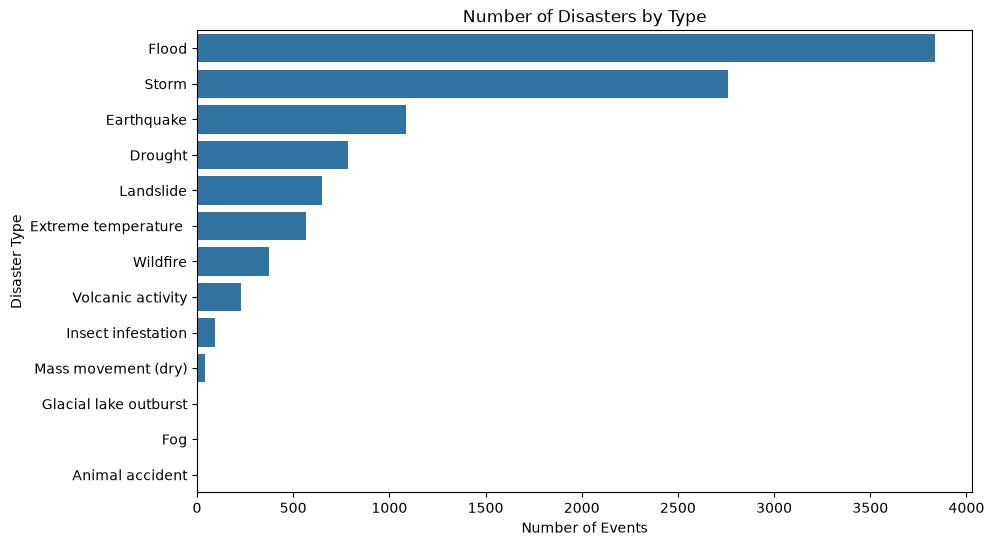

In [7]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="Disaster Type",
    order=df["Disaster Type"].value_counts().index
)

plt.title("Number of Disasters by Type")
plt.xlabel("Number of Events")
plt.ylabel("Disaster Type")

plt.show()

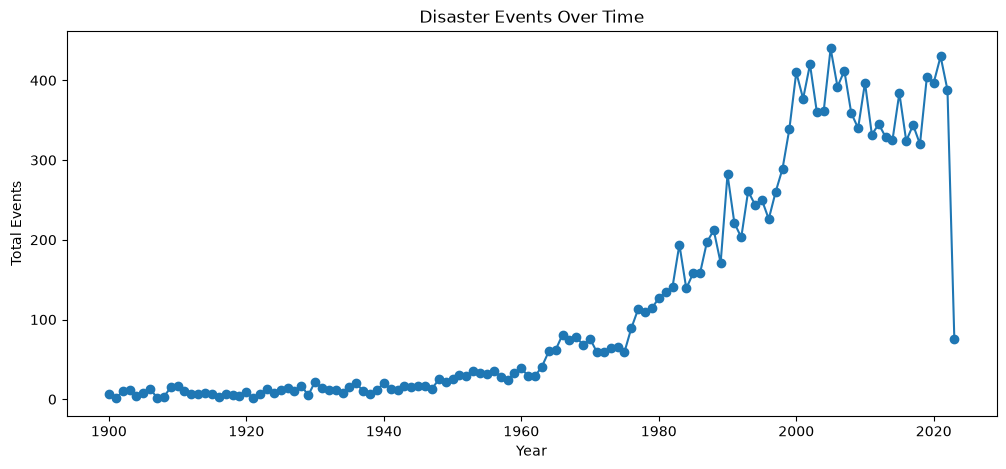

In [8]:
yearly_events = df.groupby("Year")["Total Events"].sum()

plt.figure(figsize=(12, 5))

plt.plot(
    yearly_events.index,
    yearly_events.values,
    marker="o"
)

plt.title("Disaster Events Over Time")
plt.xlabel("Year")
plt.ylabel("Total Events")

plt.show()

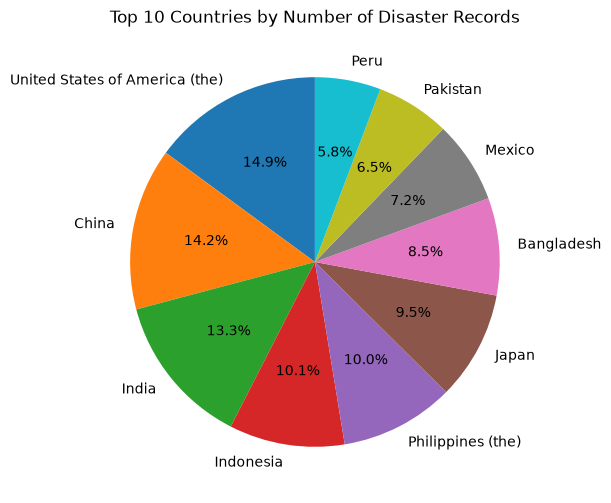

In [9]:
country = df["Country"].value_counts().head(10)

plt.figure(figsize=(10, 6))

plt.pie(
    country,
    labels=country.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 10 Countries by Number of Disaster Records")

plt.show()

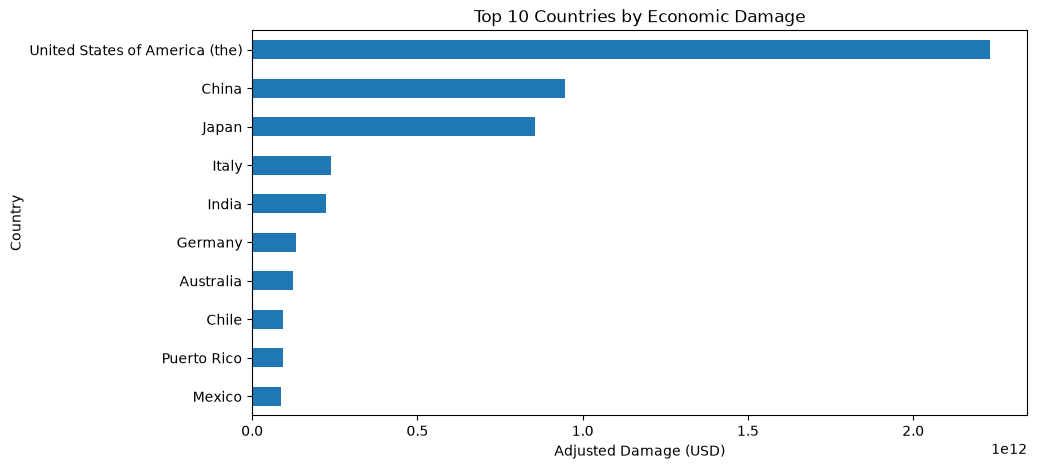

In [10]:
country_damage = (
    df.groupby("Country")["Total Damage (USD, adjusted)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))

country_damage.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Economic Damage")
plt.xlabel("Adjusted Damage (USD)")
plt.ylabel("Country")

plt.show()

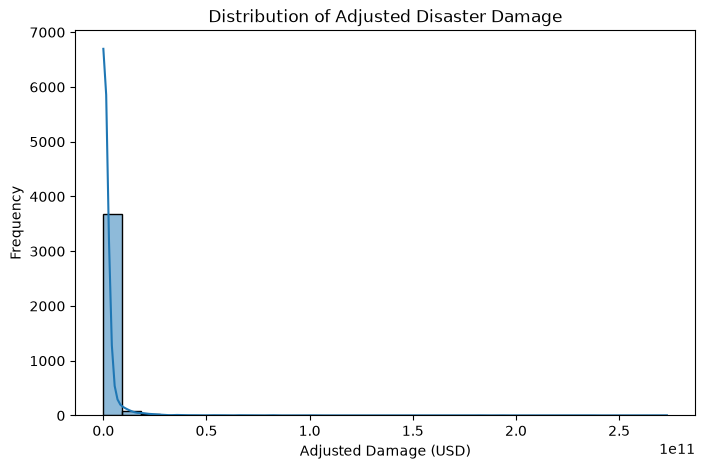

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Total Damage (USD, adjusted)"],
    bins=30,
    kde=True
)

plt.title("Distribution of Adjusted Disaster Damage")
plt.xlabel("Adjusted Damage (USD)")
plt.ylabel("Frequency")

plt.show()

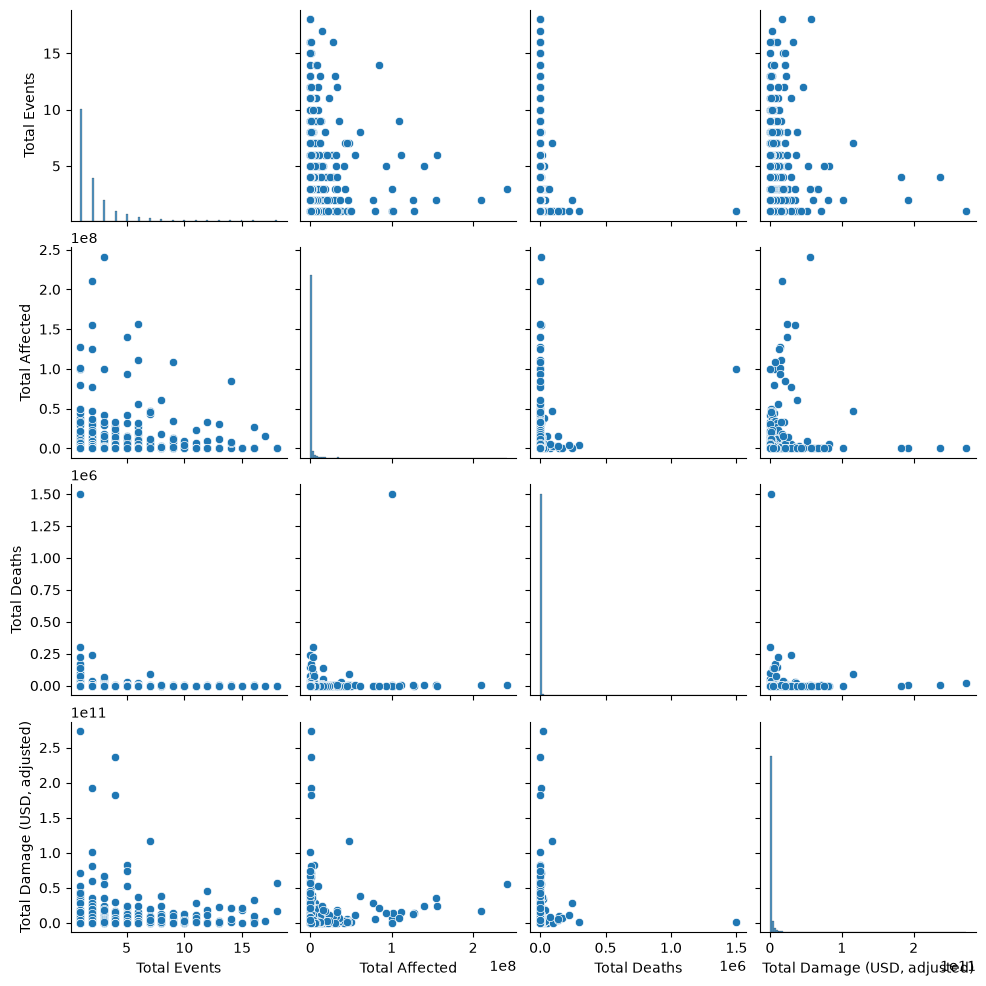

In [12]:
sns.pairplot(
    df[
        [
            "Total Events",
            "Total Affected",
            "Total Deaths",
            "Total Damage (USD, adjusted)"
        ]
    ].dropna()
)

plt.show()

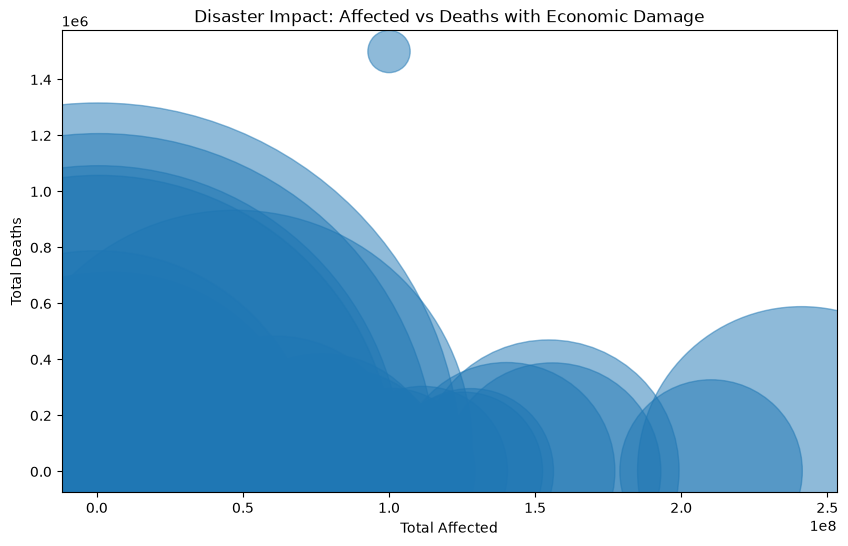

In [13]:
bubble_data = df.dropna(
    subset=[
        "Total Affected",
        "Total Deaths",
        "Total Damage (USD, adjusted)"
    ]
)

plt.figure(figsize=(10, 6))

plt.scatter(
    bubble_data["Total Affected"],
    bubble_data["Total Deaths"],
    s=bubble_data["Total Damage (USD, adjusted)"] / 1000000,
    alpha=0.5
)

plt.xlabel("Total Affected")
plt.ylabel("Total Deaths")
plt.title("Disaster Impact: Affected vs Deaths with Economic Damage")

plt.show()

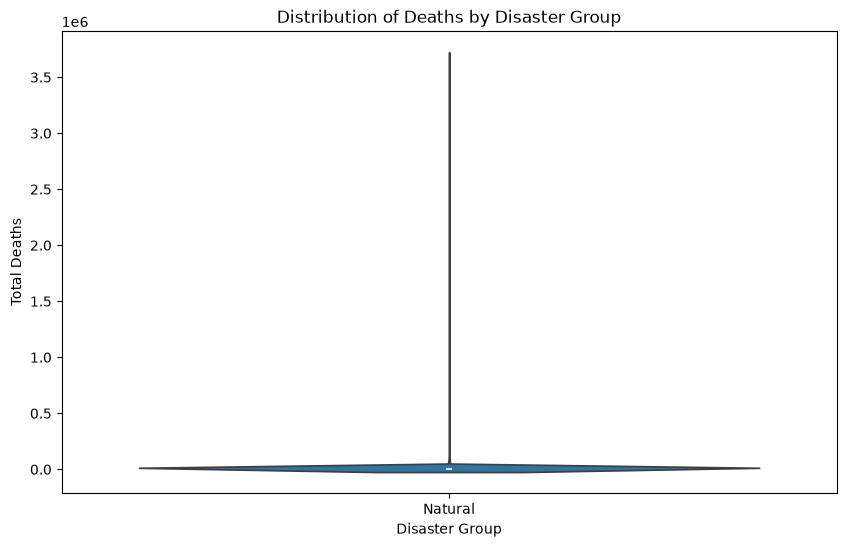

In [14]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Disaster Group",
    y="Total Deaths"
)

plt.title("Distribution of Deaths by Disaster Group")
plt.xlabel("Disaster Group")
plt.ylabel("Total Deaths")

plt.show()

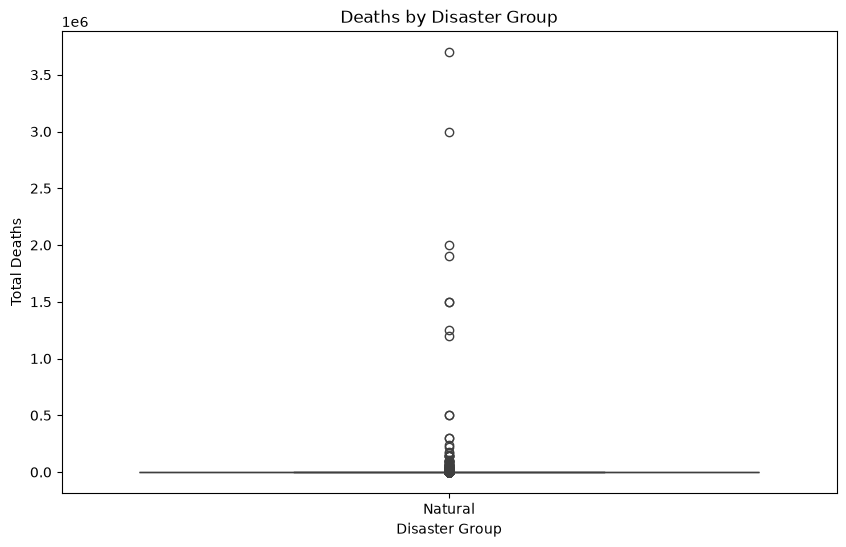

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Disaster Group",
    y="Total Deaths"
)

plt.title("Deaths by Disaster Group")
plt.xlabel("Disaster Group")
plt.ylabel("Total Deaths")

plt.show()